### Confidence Intervals: Intuition

Before data → “I know how the machine works”
This means we have a rule (based on the Central Limit Theorem) that tells us how to construct an interval for any possible sample. At this stage, the sample mean $\bar{X}$ is still random, so the interval is also random.

After data → “I pressed the machine once”
Now we observe one specific sample, compute $\bar{X}$, and obtain one fixed interval. The randomness is gone because the data is fixed.

A confidence interval is a procedure derived using the Central Limit Theorem (CLT):

$$
\bar{X} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}
$$

Before observing data, $\bar{X}$ is random, so the interval is random. After observing one sample, the interval becomes fixed.

That’s why probability statements are about the **procedure**, not a single computed interval: over many samples, the procedure produces intervals that contain the true parameter $\mu$ with a given frequency (e.g., 95%).


# Statistical Inference Roadmap (CLT → Asymptotics → Bootstrap)

**Statistical inference** is the framework for making probabilistic statements about unknown population parameters based on a random sample, typically through estimation, hypothesis testing, and confidence intervals.

| Step | Concept | What You Do | Key Equation | Purpose | Intuition | Source |
|------|--------|-------------|-------------|---------|-----------|--------|
| 1 | Data Generating Process (DGP) | Assume i.i.d. data | $E[X]=\mu,\; Var(X)=\sigma^2$ | Define probabilistic model | Data comes from an unknown distribution | Casella & Berger (2002); Hayashi (2000) |
| 2 | Sample Mean | Compute estimator | $\bar{X} = \frac{1}{n}\sum X_i$ | Estimate $\mu$ | Averaging reduces noise | Casella & Berger (2002) |
| 3 | Variance of Estimator | Derive variability | $Var(\bar{X}) = \frac{\sigma^2}{n}$ | Quantify dispersion of estimator | Larger samples reduce variance | Casella & Berger (2002) |
| 4 | Standard Error (SE) | Take square root | $SE(\bar{X}) = \frac{\sigma}{\sqrt{n}}$ | Measure estimation uncertainty | Typical estimation error size | Wooldridge (2010); Hayashi (2000) |
| 5 | Consistency | Show convergence in probability | $\bar{X} \xrightarrow{p} \mu$ | Ensure estimator approaches true value | Error vanishes as $n$ increases | Casella & Berger (2002); Hayashi (2000) |
| 6 | Root-n Rate | Express convergence speed | $\bar{X} - \mu = O_p(1/\sqrt{n})$ | Describe asymptotic rate | Error shrinks at $1/\sqrt{n}$ | Hayashi (2000); Greene (2018) |
| 7 | Scaling | Rescale estimator | $\sqrt{n}(\bar{X}-\mu)$ | Obtain non-degenerate limit | Keeps variability finite | Hayashi (2000) |
| 8 | Constant Variance | Compute variance after scaling | $Var(\sqrt{n}(\bar{X}-\mu)) = \sigma^2$ | Ensure stable variance | Neither vanishes nor explodes | Casella & Berger (2002) |
| 9 | Central Limit Theorem (CLT) | Derive limiting distribution | $\sqrt{n}(\bar{X}-\mu) \rightarrow \mathcal{N}(0,\sigma^2)$ | Characterize sampling distribution | Normal approximation emerges | Lindeberg–Levy CLT; Billingsley (1995) |
| 10 | t-Statistic | Replace unknown variance | $\frac{\bar{X}-\mu}{s/\sqrt{n}} \sim t_{n-1}$ | Enable inference with estimated variance | Accounts for extra uncertainty | Casella & Berger (2002) |
| 11 | Confidence Interval | Construct interval | $\bar{X} \pm t \cdot \frac{s}{\sqrt{n}}$ | Interval estimation for $\mu$ | Range of plausible values | Wooldridge (2010) |
| 12 | Monte Carlo | Simulate from assumed model | Generate repeated samples from chosen distribution | Approximate sampling distribution numerically | Recreate repeated sampling | Glasserman (2004); Kroese et al. (2011) |
| 13 | Bootstrap | Resample observed data | Resample $X_1,...,X_n$ with replacement | Estimate sampling variability without parametric assumptions | Treat sample as population | Efron & Tibshirani (1993); Davison & Hinkley (1997) |

---

# Key Takeaways

- Consistency: $\bar{X} \xrightarrow{p} \mu$  
- Variance of the mean is $\sigma^2/n$  
- Standard error is $\sigma/\sqrt{n}$  
- Root-n rate determines convergence speed  
- Scaling by $\sqrt{n}$ yields a stable distribution  
- CLT provides asymptotic normality  
- Bootstrap estimates variability directly from data  

# Step 1 — Data Generating Process (DGP)

### Definition
We assume the data comes from an underlying probabilistic model:

- $X_1, X_2, ..., X_n \sim \text{i.i.d.}$
- $E[X_i] = \mu$
- $Var(X_i) = \sigma^2$

### What this means
- Each observation is drawn from the same distribution  
- Observations are independent  
- The true parameters $\mu$ and $\sigma^2$ are unknown  

### Purpose
Define the **population model** we want to learn about.

### Intuition
There is a “true world” generating data — we just observe a sample from it.

---

# Step 2 — Sample Mean (Estimator)

### Definition
We estimate the population mean $\mu$ using:

$$
\bar{X} = \frac{1}{n}\sum_{i=1}^{n} X_i
$$

### Properties
- $E[\bar{X}] = \mu$ → unbiased  
- Uses all available data  

### Purpose
Provide a **point estimate** of the unknown population mean.

### Intuition
Averaging cancels out random noise and reveals the underlying signal.

---

# Step 3 — Variance of the Estimator

### Result
$$
Var(\bar{X}) = \frac{\sigma^2}{n}
$$

### Derivation (key idea)
- Independence ⇒ variances add  
- Scaling by $1/n$ reduces variance  

$$
Var\left(\frac{1}{n}\sum X_i\right)
= \frac{1}{n^2} \sum Var(X_i)
= \frac{\sigma^2}{n}
$$

### Purpose
Measure how much the estimator varies across repeated samples.

### Intuition
- More data ⇒ less variability  
- Variance shrinks at rate $1/n$

---

# Step 4 — Standard Error (SE)

### Definition
The standard error is the standard deviation of the estimator:

$$
SE(\bar{X}) = \sqrt{Var(\bar{X})} = \frac{\sigma}{\sqrt{n}}
$$

### In practice
Since $\sigma$ is unknown:

$$
SE(\bar{X}) \approx \frac{s}{\sqrt{n}}
$$

where $s$ is the sample standard deviation.

### Purpose
Quantify the **typical size of estimation error**.

### Intuition
- Error shrinks as sample size increases  
- The rate is $1/\sqrt{n}$  
- This is the key link to asymptotics

---

# Summary of Steps 1–4

- Data comes from an unknown distribution  
- We estimate the mean using $\bar{X}$  
- The variability of $\bar{X}$ is $\sigma^2/n$  
- The typical estimation error is $\sigma/\sqrt{n}$  

In [1]:
import numpy as np

# -----------------------------
# Step 1 — Data Generating Process (DGP)
# -----------------------------
np.random.seed(42)

mu = 5            # true mean
sigma = 2         # true standard deviation
n = 50            # sample size
B = 10000         # number of simulations (Monte Carlo)

# -----------------------------
# Step 2 — Sample Mean
# -----------------------------
# Generate B samples, each of size n
samples = np.random.normal(mu, sigma, size=(B, n))

# Compute sample mean for each sample
sample_means = samples.mean(axis=1)

# -----------------------------
# Step 3 — Variance of the Estimator
# -----------------------------
# Empirical variance of sample mean
var_empirical = np.var(sample_means, ddof=1)

# Theoretical variance
var_theoretical = sigma**2 / n

# -----------------------------
# Step 4 — Standard Error (SE)
# -----------------------------
# Empirical standard deviation of sample means
se_empirical = np.std(sample_means, ddof=1)

# Theoretical standard error
se_theoretical = sigma / np.sqrt(n)

# -----------------------------
# Results
# -----------------------------
print("True mean (mu):", mu)
print("Average of sample means:", np.mean(sample_means))

print("\nVariance of sample mean:")
print("Empirical:", var_empirical)
print("Theoretical:", var_theoretical)

print("\nStandard Error:")
print("Empirical:", se_empirical)
print("Theoretical:", se_theoretical)

True mean (mu): 5
Average of sample means: 4.9976676208415425

Variance of sample mean:
Empirical: 0.08115835994458306
Theoretical: 0.08

Standard Error:
Empirical: 0.28488306363240173
Theoretical: 0.282842712474619


# Step 5 — Consistency

### Definition
An estimator is **consistent** if it converges in probability to the true parameter:

$$
\bar{X} \xrightarrow{p} \mu
$$

### What this means
For any small $\varepsilon > 0$:

$$
P(|\bar{X} - \mu| > \varepsilon) \to 0 \quad \text{as } n \to \infty
$$

### Why it holds
Using Chebyshev’s inequality:

$$
P(|\bar{X} - \mu| > \varepsilon) \le \frac{Var(\bar{X})}{\varepsilon^2}
= \frac{\sigma^2}{n \varepsilon^2}
$$

As $n \to \infty$, this goes to 0.

### Purpose
Guarantee that the estimator becomes accurate with more data.

### Intuition
As the sample size increases, the estimator “locks onto” the true value.

---

# Step 6 — Root-n Rate

### Definition
The estimation error shrinks at rate $1/\sqrt{n}$:

$$
\bar{X} - \mu = O_p(1/\sqrt{n})
$$

### Equivalent form
$$
\sqrt{n}(\bar{X} - \mu) = O_p(1)
$$

### What this means
- The error does not vanish arbitrarily fast  
- Its magnitude is proportional to $1/\sqrt{n}$  

### Purpose
Describe the **speed of convergence**.

### Intuition
Doubling the sample size does not halve the error — improvement is slower.

---

# Step 7 — Scaling

### Definition
Rescale the estimator:

$$
\sqrt{n}(\bar{X} - \mu)
$$

### Why scaling is needed
- Without scaling: $\bar{X} - \mu \to 0$  
- With scaling: randomness is preserved  

### Resulting variance
$$
Var(\sqrt{n}(\bar{X} - \mu)) = \sigma^2
$$

### Purpose
Create a non-degenerate random variable for analysis.

### Intuition
Scaling “zooms in” on the shrinking estimation error.

---

# Step 8 — Constant Variance

### Result
$$
Var(\sqrt{n}(\bar{X} - \mu)) = \sigma^2
$$

### Why this matters
- Variance does not go to 0  
- Variance does not explode  
- The distribution remains stable  

### Purpose
Ensure a meaningful limiting distribution exists.

### Intuition
This scaling balances shrinkage exactly — neither too small nor too large.

---

# Summary of Steps 5–8

- Consistency: estimator converges to the true value  
- Root-n rate: error shrinks at $1/\sqrt{n}$  
- Scaling: rescales error to preserve randomness  
- Constant variance: ensures stability for asymptotic analysis  

Average |X̄ - μ| (consistency check):
n=10: 0.5155
n=50: 0.2260
n=100: 0.1592
n=500: 0.0703
n=1000: 0.0501
n=10000: 0.0160

Variance of √n(X̄ - μ) (should be ≈ σ² = 4):
n=10: 4.1411
n=50: 4.0157
n=100: 3.9706
n=500: 3.9132
n=1000: 3.9717
n=10000: 4.0232


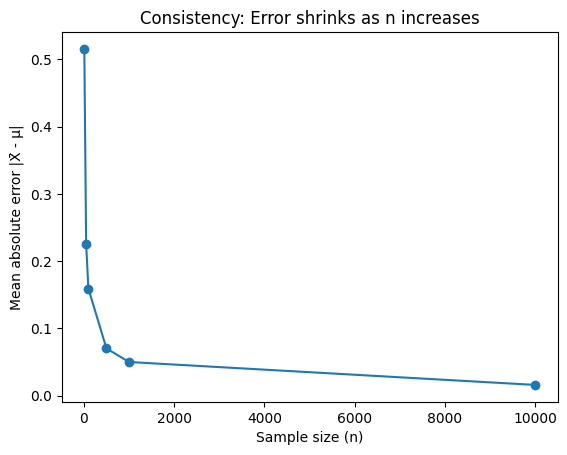

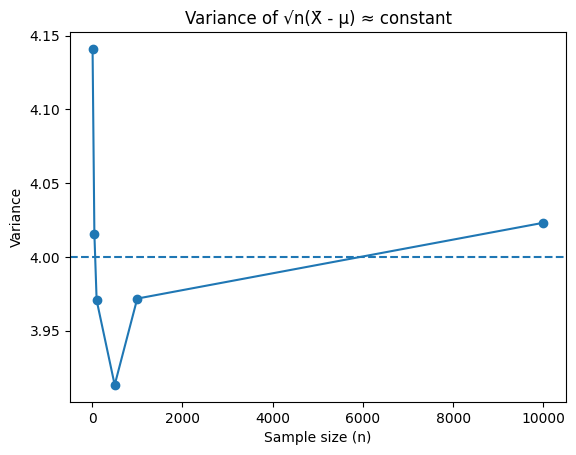

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# True parameters
mu = 5
sigma = 2

# Sample sizes to study convergence
n_list = [10, 50, 100, 500, 1000, 10000]
B = 10000  # number of simulations

# Store results
mean_errors = []
scaled_variances = []

for n in n_list:
    # Generate B samples of size n
    samples = np.random.normal(mu, sigma, size=(B, n))
    
    # Sample means
    sample_means = samples.mean(axis=1)
    
    # -------- Step 5: Consistency --------
    error = sample_means - mu
    mean_abs_error = np.mean(np.abs(error))
    mean_errors.append(mean_abs_error)
    
    # -------- Step 6–7: Scaling --------
    scaled = np.sqrt(n) * error
    
    # -------- Step 8: Constant variance --------
    var_scaled = np.var(scaled, ddof=1)
    scaled_variances.append(var_scaled)

# -----------------------------
# Print results
# -----------------------------
print("Average |X̄ - μ| (consistency check):")
for n, e in zip(n_list, mean_errors):
    print(f"n={n}: {e:.4f}")

print("\nVariance of √n(X̄ - μ) (should be ≈ σ² = 4):")
for n, v in zip(n_list, scaled_variances):
    print(f"n={n}: {v:.4f}")

# -----------------------------
# Plot consistency
# -----------------------------
plt.figure()
plt.plot(n_list, mean_errors, marker='o')
plt.title("Consistency: Error shrinks as n increases")
plt.xlabel("Sample size (n)")
plt.ylabel("Mean absolute error |X̄ - μ|")
plt.show()

# -----------------------------
# Plot scaled variance stability
# -----------------------------
plt.figure()
plt.plot(n_list, scaled_variances, marker='o')
plt.axhline(y=sigma**2, linestyle='--')
plt.title("Variance of √n(X̄ - μ) ≈ constant")
plt.xlabel("Sample size (n)")
plt.ylabel("Variance")
plt.show()

In [ ]:
# Step 9 — Central Limit Theorem (CLT)

### Definition
The scaled sample mean converges in distribution to a normal distribution:

$$
\sqrt{n}(\bar{X} - \mu) \rightarrow \mathcal{N}(0,\sigma^2)
$$

### What this means
- Even if the original data is not normal  
- The sample mean becomes approximately normal for large $n$

### Purpose
Characterize the sampling distribution of the estimator.

### Intuition
Averaging many random variables produces a normal distribution.

---

# Step 10 — t-Statistic

### Definition
When $\sigma$ is unknown, replace it with sample standard deviation $s$:

$$
t = \frac{\bar{X} - \mu}{s/\sqrt{n}}
$$

### Distribution
$$
t \sim t_{n-1}
$$

### What this means
- We standardize the estimator  
- But account for estimation of variance  

### Purpose
Enable statistical inference when $\sigma$ is unknown.

### Intuition
Estimating variance introduces extra uncertainty → heavier tails.

---

# Step 11 — Confidence Interval

### Definition
A $(1-\alpha)$ confidence interval for $\mu$ is:

$$
\bar{X} \pm t_{\alpha/2,\,n-1} \cdot \frac{s}{\sqrt{n}}
$$

### Example (95%)
$$
\bar{X} \pm t_{0.025,\,n-1} \cdot \frac{s}{\sqrt{n}}
$$

### What this means
- The interval is random  
- The parameter $\mu$ is fixed  

### Interpretation (important)
In repeated samples, $(1-\alpha)$ proportion of intervals contain $\mu$.

### Purpose
Provide a range of plausible values for the true parameter.

### Intuition
Sampling uncertainty creates a band around the estimate.

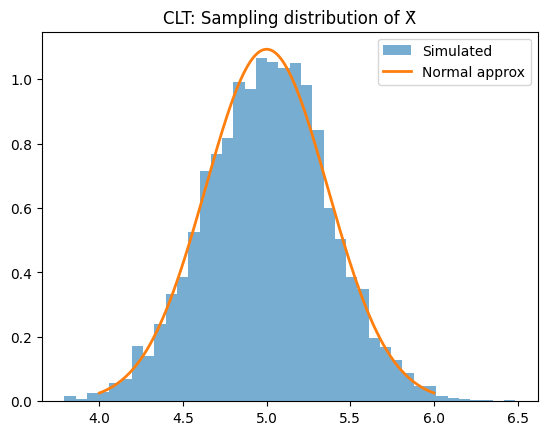

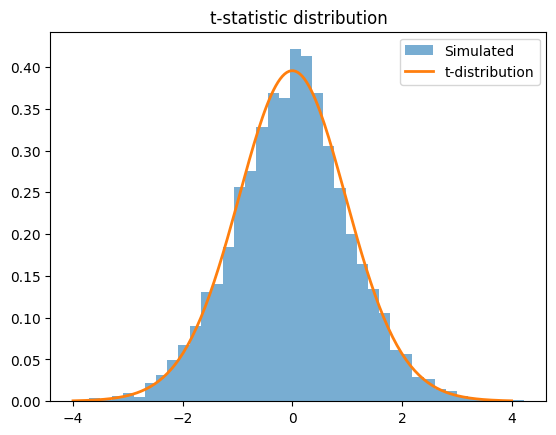

Sample mean: 4.923205164689053
95% Confidence interval: (np.float64(4.301432074388348), np.float64(5.544978254989758))
Coverage probability: 0.9472


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Parameters
mu = 5
sigma = 2
n = 30
B = 5000

# ----------------------------------
# Step 9 — CLT (sampling distribution)
# ----------------------------------
means = []

for _ in range(B):
    sample = np.random.normal(mu, sigma, n)
    means.append(np.mean(sample))

means = np.array(means)

# Plot sampling distribution of X̄
plt.figure()
plt.hist(means, bins=40, density=True, alpha=0.6, label="Simulated")

x = np.linspace(mu - 1, mu + 1, 200)
plt.plot(x, stats.norm.pdf(x, mu, sigma/np.sqrt(n)), linewidth=2, label="Normal approx")

plt.title("CLT: Sampling distribution of X̄")
plt.legend()
plt.show()

# ----------------------------------
# Step 10 — t-statistic
# ----------------------------------
t_values = []

for _ in range(B):
    sample = np.random.normal(mu, sigma, n)
    
    x_bar = np.mean(sample)
    s = np.std(sample, ddof=1)
    
    t = (x_bar - mu) / (s / np.sqrt(n))
    t_values.append(t)

t_values = np.array(t_values)

# Plot t-statistic distribution
plt.figure()
plt.hist(t_values, bins=40, density=True, alpha=0.6, label="Simulated")

x = np.linspace(-4, 4, 200)
plt.plot(x, stats.t.pdf(x, df=n-1), linewidth=2, label="t-distribution")

plt.title("t-statistic distribution")
plt.legend()
plt.show()

# ----------------------------------
# Step 11 — Confidence Interval
# ----------------------------------
# One sample
sample = np.random.normal(mu, sigma, n)

x_bar = np.mean(sample)
s = np.std(sample, ddof=1)

t_crit = stats.t.ppf(0.975, df=n-1)

lower = x_bar - t_crit * s / np.sqrt(n)
upper = x_bar + t_crit * s / np.sqrt(n)

print("Sample mean:", x_bar)
print("95% Confidence interval:", (lower, upper))

# ----------------------------------
# Coverage check (important insight)
# ----------------------------------
count = 0

for _ in range(B):
    sample = np.random.normal(mu, sigma, n)
    
    x_bar = np.mean(sample)
    s = np.std(sample, ddof=1)
    
    lower = x_bar - t_crit * s / np.sqrt(n)
    upper = x_bar + t_crit * s / np.sqrt(n)
    
    if lower <= mu <= upper:
        count += 1

print("Coverage probability:", count / B)

# Step 12 — Monte Carlo Simulation

### Definition
Monte Carlo simulation approximates the sampling distribution by repeatedly generating data from an assumed model.

### Procedure
1. Specify a data-generating process (DGP)  
2. Simulate many samples of size $n$  
3. Compute the estimator (e.g., $\bar{X}$) for each sample  
4. Analyze the distribution of these estimates  

### Key Idea
$$
\{\bar{X}^{(1)}, \bar{X}^{(2)}, ..., \bar{X}^{(B)}\}
$$

### Purpose
Approximate the sampling distribution numerically.

### Intuition
Recreate repeated sampling from the true model using a computer.

---

# Step 13 — Bootstrap

### Definition
Bootstrap estimates the sampling distribution by resampling from the observed data.

### Procedure
1. Start with observed sample $X_1, ..., X_n$  
2. Draw samples with replacement from this data  
3. Compute estimator for each resample  
4. Repeat many times  

### Key Idea
$$
\{\bar{X}^{*(1)}, \bar{X}^{*(2)}, ..., \bar{X}^{*(B)}\}
$$

### Purpose
Estimate sampling variability without assuming a parametric model.

### Intuition
Treat the sample as a proxy for the population.

---

# Key Difference

| Monte Carlo | Bootstrap |
|------------|----------|
| Uses assumed model | Uses observed data |
| Requires known distribution | No distribution assumption |
| Simulates true population | Resamples sample |

Monte Carlo mean: 5.003669187402808
Monte Carlo variance: 0.13579787516430783

Bootstrap mean: 5.453623497121845
Bootstrap variance: 0.0878757104600184


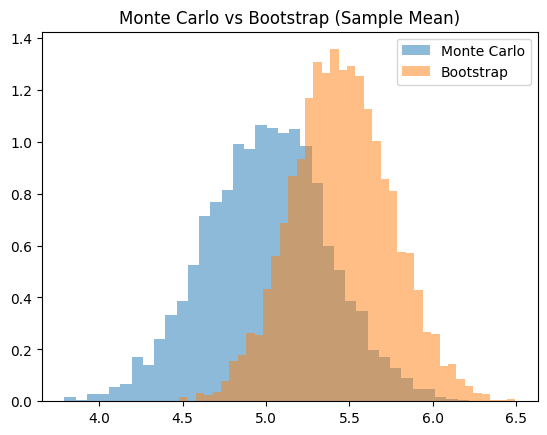


Bootstrap SE: 0.2964383754847176
Bootstrap 95% CI: (np.float64(4.870926617846644), np.float64(6.041177998342249))


In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Parameters
mu = 5
sigma = 2
n = 30
B = 5000

# ----------------------------------
# Step 12 — Monte Carlo
# ----------------------------------
mc_means = []

for _ in range(B):
    sample = np.random.normal(mu, sigma, n)
    mc_means.append(np.mean(sample))

mc_means = np.array(mc_means)

print("Monte Carlo mean:", np.mean(mc_means))
print("Monte Carlo variance:", np.var(mc_means, ddof=1))


# ----------------------------------
# Step 13 — Bootstrap
# ----------------------------------
# One observed sample
original_sample = np.random.normal(mu, sigma, n)

boot_means = []

for _ in range(B):
    resample = np.random.choice(original_sample, size=n, replace=True)
    boot_means.append(np.mean(resample))

boot_means = np.array(boot_means)

print("\nBootstrap mean:", np.mean(boot_means))
print("Bootstrap variance:", np.var(boot_means, ddof=1))


# ----------------------------------
# Plot comparison
# ----------------------------------
plt.figure()

plt.hist(mc_means, bins=40, density=True, alpha=0.5, label="Monte Carlo")
plt.hist(boot_means, bins=40, density=True, alpha=0.5, label="Bootstrap")

plt.title("Monte Carlo vs Bootstrap (Sample Mean)")
plt.legend()
plt.show()


# ----------------------------------
# Bootstrap Standard Error
# ----------------------------------
boot_se = np.std(boot_means, ddof=1)
print("\nBootstrap SE:", boot_se)


# ----------------------------------
# Bootstrap Confidence Interval
# ----------------------------------
lower = np.percentile(boot_means, 2.5)
upper = np.percentile(boot_means, 97.5)

print("Bootstrap 95% CI:", (lower, upper))